# Recommendation System

This notebook uses the best trained classifiers to identify client investment needs,
then maps those needs to product recommendations.

**Model outputs are loaded from pre-computed pickles** — no retraining needed.
Run all `utils/*.py` scripts first to populate `data/pickled_files/`.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

sys.path.insert(0, str(Path().resolve()))
from utils.preprocessing import (
    BASELINE_FEATURE_NAMES,
    FEATURE_NAMES,
    TARGETS,
    build_baseline_features,
    build_features,
    get_propensity_scores,
    load_data,
    split_data,
    load_result,
)
from utils.products import build_interaction_matrix, check_interaction_matrix, get_products
from utils.svd_rec import fit_svd, recommend_svd, score_all_svd, select_k
from utils.autoencoder_rec import (
    recommend_ae,
    score_all_ae,
    select_k_ae,
    train_autoencoder,
)

PICKLE_ROOT = Path('data/pickled_files')

## Best model outputs

Load the best model per target (update `BEST_MODELS` once `bestmodel_*.ipynb` identifies winners).

In [2]:
BEST_MODELS = {
    'IncomeInvestment':       'xgboost_shap',
    'AccumulationInvestment': 'xgboost_shap',
}

best_results = {}
for target, folder in BEST_MODELS.items():
    try:
        best_results[target] = load_result(folder, target)
        tm = best_results[target]['test_metrics']
        print(f"[{folder}] {target} — "
              f"F1: {tm['f1']:.3f}  "
              f"Precision: {tm['precision']:.3f}  "
              f"Recall: {tm['recall']:.3f}")
    except FileNotFoundError as e:
        print(f"MISSING: {e}")

[xgboost_shap] IncomeInvestment — F1: 0.641  Precision: 0.821  Recall: 0.526
[xgboost_shap] AccumulationInvestment — F1: 0.792  Precision: 0.835  Recall: 0.752


## Best model test-set metrics (reference)

In [3]:
rows = []
for target, r in best_results.items():
    row = {'target': target, 'model': r.get('model_name', BEST_MODELS[target])}
    row.update({k: round(v, 3) for k, v in r['test_metrics'].items()})
    rows.append(row)

pd.DataFrame(rows).set_index('target')

,model,accuracy,precision,recall,f1
target,,,,,
IncomeInvestment,XGBoost,0.774,0.821,0.526,0.641
AccumulationInvestment,XGBoost,0.797,0.835,0.752,0.792


## SHAP global importances (from XGBoost pickle)

In [4]:
for target in TARGETS:
    xgb_path = PICKLE_ROOT / 'xgboost_shap' / f'{target.lower()}.joblib'
    if not xgb_path.exists():
        print(f'XGBoost pickle missing for {target}')
        continue

    r = joblib.load(xgb_path)
    shap_values = r['shap_values']
    shap_test_X = r['shap_test_X']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    plt.sca(axes[0])
    shap.summary_plot(shap_values, shap_test_X, plot_type='bar', show=False)
    axes[0].set_title(f'Mean |SHAP| — {target}')

    plt.sca(axes[1])
    shap.summary_plot(shap_values, shap_test_X, show=False)
    axes[1].set_title(f'SHAP Beeswarm — {target}')

    plt.tight_layout()
    plt.show()

XGBoost pickle missing for IncomeInvestment
XGBoost pickle missing for AccumulationInvestment


---
## Recommendation system

> **To be implemented.** Use the loaded `best_results` models and SHAP outputs above
> as inputs to the recommendation logic below.

In [5]:
# Load full dataset for inference
df = load_data()
X = build_features(df)
df.head()

,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


---
## Stage 1 — Propensity scores on full dataset

Apply the best pickled model per target to all 5,000 clients to produce
calibrated propensity scores p̂ ∈ [0,1] and binary need flags.

The threshold comes from `threshold_metrics` in each pickle: it is the
PR-curve optimal cut-point selected on a held-out validation set subject
to precision ≥ 0.75 (MiFID II floor).  It is never re-derived here.

In [6]:
df    = load_data()
X_fe  = build_features(df)
X_fb  = build_baseline_features(df)

clients_df = df[['RiskPropensity']].copy().reset_index(drop=True)

_need_col = {
    'IncomeInvestment':       ('p_hat_income', 'need_income'),
    'AccumulationInvestment': ('p_hat_accum',  'need_accum'),
}

for target, (col_phat, col_need) in _need_col.items():
    if target not in best_results:
        print(f'Skipping {target} — pickle not loaded')
        continue

    r          = best_results[target]
    model      = r['model']
    scaler     = r['scaler']
    feat_names = r['feature_names']

    # Select feature matrix matching the model's training set
    X = X_fb if feat_names == BASELINE_FEATURE_NAMES else X_fe

    # Apply scaler only when stored separately (MLP pattern);
    # Pipeline-based models handle scaling internally.
    if scaler is not None:
        X_in = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)
    else:
        X_in = X

    # Threshold fixed on validation set — not re-optimised here
    thr_info  = r.get('threshold_metrics') or r.get('threshold_info')
    threshold = thr_info['threshold'] if thr_info else 0.5

    clients_df[col_phat] = get_propensity_scores(model, X_in)
    clients_df[col_need] = (clients_df[col_phat] >= threshold).astype(bool)

print(f"Clients with income need  : {clients_df['need_income'].sum()} "
      f"({clients_df['need_income'].mean():.1%})")
print(f"Clients with accum need   : {clients_df['need_accum'].sum()} "
      f"({clients_df['need_accum'].mean():.1%})")
print(f"Clients with either need  : "
      f"{(clients_df['need_income'] | clients_df['need_accum']).sum()}")
clients_df.head()

Clients with income need  : 1889 (37.8%)
Clients with accum need   : 2543 (50.9%)
Clients with either need  : 3465


,RiskPropensity,p_hat_income,need_income,p_hat_accum,need_accum
0,0.233355,0.196407,False,0.984696,True
1,0.170911,0.954745,True,0.199184,False
2,0.249703,0.198589,False,0.222250,False
3,0.654597,1.000000,True,1.000000,True
4,0.349039,0.198589,False,0.217692,False


---
## Stage 2 — Product catalogue & interaction matrix

**Product catalogue**: 11 products (6 Accumulation, 5 Income) with SRI ∈ [0.12, 0.88].

**Interaction matrix R ∈ {0,1}^(5000×11)**: built via revealed preference.
For each need type where the client's label is 1, the interaction is assigned
to the product whose SRI is closest to the client's `RiskPropensity` — the
utility-maximising choice under mean-variance preferences.

Interaction matrix checks
  Shape                   : (5000, 11)  [OK]
  Binary values           : [OK]
  Max interactions/client : 2  [OK]
  Total interactions      : 4484  [OK]
  Matrix density          : 8.15%
---------------------------------------------
  Clients with 0 interactions : 1514
  Clients with 1 interaction  : 2488
  Clients with 2 interactions : 998

  All checks passed: [OK]


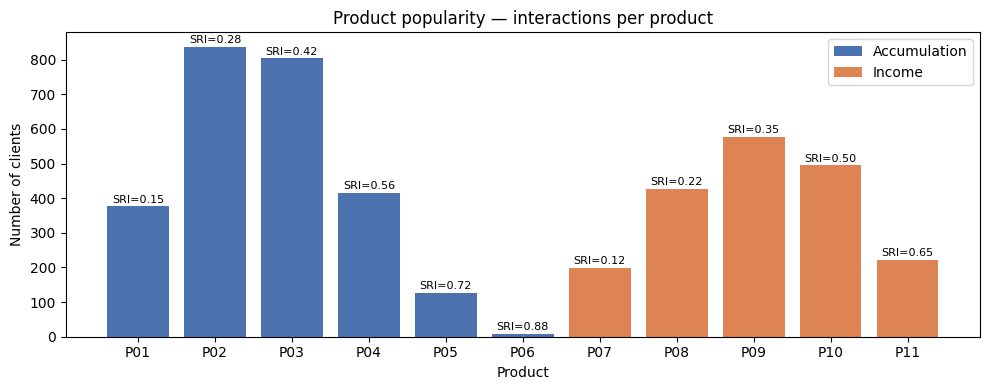


products_df:
product_id         type  SRI
       P01 Accumulation 0.15
       P02 Accumulation 0.28
       P03 Accumulation 0.42
       P04 Accumulation 0.56
       P05 Accumulation 0.72
       P06 Accumulation 0.88
       P07       Income 0.12
       P08       Income 0.22
       P09       Income 0.35
       P10       Income 0.50
       P11       Income 0.65


In [7]:
products_df = get_products()
R           = build_interaction_matrix(df, products_df)
stats       = check_interaction_matrix(R, products_df, plot=True)

print(f"\nproducts_df:\n{products_df.to_string(index=False)}")

---
## Stage 3a — SVD: rank selection

Rank k is chosen by holding out 20% of known positive interactions and
measuring held-out AUC for each candidate k.

Only 1-entries are held out: R=0 means "not yet purchased", not "disliked".
Evaluating on randomly sampled zeros would inflate AUC without measuring
collaborative filtering quality.

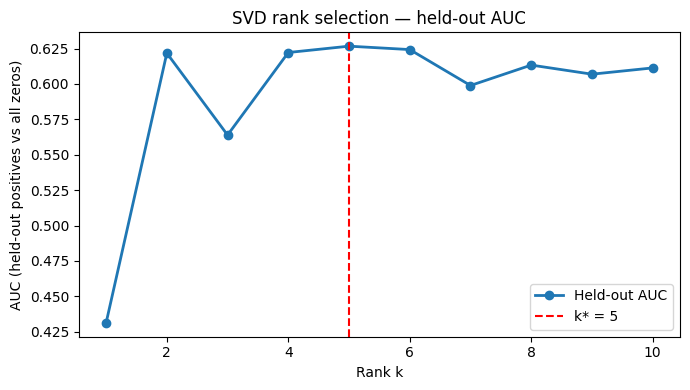

k* = 5  (held-out AUC = 0.6267)

Full AUC curve:
  k= 1  AUC=0.4312
  k= 2  AUC=0.6218
  k= 3  AUC=0.5639
  k= 4  AUC=0.6222
  k= 5  AUC=0.6267 <-- k*
  k= 6  AUC=0.6243
  k= 7  AUC=0.5989
  k= 8  AUC=0.6133
  k= 9  AUC=0.6069
  k=10  AUC=0.6113


In [8]:
k_results = select_k(R, k_range=range(1, 11), val_frac=0.2, random_state=42, plot=True)
K_STAR    = k_results['k_star']

print("\nFull AUC curve:")
for k, auc in sorted(k_results['auc_scores'].items()):
    marker = " <-- k*" if k == K_STAR else ""
    print(f"  k={k:2d}  AUC={auc:.4f}{marker}")

---
## Stage 3b — SVD: decomposition & scoring

Fit the truncated SVD at rank k* and compute the full (5000 × 11) score
matrix R̂ = U Σ V^T.

The latent dimensions in U (client embeddings) and V^T (product embeddings)
represent co-purchase patterns.  Clients with similar purchase histories
are mapped to nearby points in ℝ^k; products bought by the same types of
clients are mapped to nearby points.  The inner product r̂_cp measures how
well the client's latent profile aligns with the product's latent profile.

Latent dimensions  : k* = 5
Singular values    : [31.318 29.598 23.964 21.766 20.722]
R_hat_svd shape    : (5000, 11)
Score range        : [-0.2196, 1.1205]


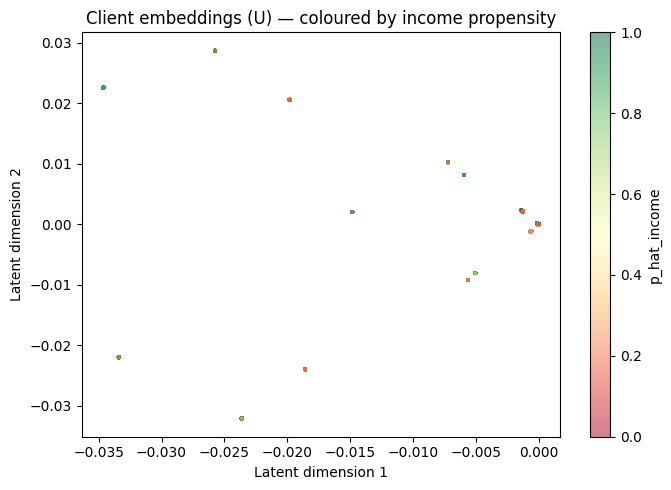

In [9]:
U, sigma, Vt = fit_svd(R, k=K_STAR)
R_hat_svd    = score_all_svd(U, sigma, Vt)

print(f"Latent dimensions  : k* = {K_STAR}")
print(f"Singular values    : {np.round(sigma, 3)}")
print(f"R_hat_svd shape    : {R_hat_svd.shape}")
print(f"Score range        : [{R_hat_svd.min():.4f}, {R_hat_svd.max():.4f}]")

# Visualise client embeddings in the first two latent dimensions
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    U[:, 0], U[:, 1],
    c=clients_df['p_hat_income'],
    cmap='RdYlGn', s=3, alpha=0.5,
)
plt.colorbar(scatter, ax=ax, label='p_hat_income')
ax.set_xlabel('Latent dimension 1')
ax.set_ylabel('Latent dimension 2')
ax.set_title('Client embeddings (U) — coloured by income propensity')
plt.tight_layout()
plt.show()

---
## Stage 3c — SVD: constrained recommendations

For each client with a confirmed need, products are ranked by SVD score
within the MiFID II-compliant eligible set:

1. **Need type filter**: only products matching the client's confirmed need type.
2. **Risk cap**: SRI_p ≤ RiskPropensity_c (hard constraint — never relaxed).

If no product passes both filters, the client is flagged as
`no_compliant_product` and must be routed to a human advisor.

In [10]:
# Recommend for all clients with at least one confirmed need
eligible_clients = clients_df[
    clients_df['need_income'] | clients_df['need_accum']
].index.tolist()

recs_svd = recommend_svd(
    client_indices=eligible_clients,
    R_hat=R_hat_svd,
    clients_df=clients_df,
    products_df=products_df,
    top_n=1,   # top-1 per need type; change to 3 for ranked shortlist
)

# --- Coverage metrics ---
n_served   = recs_svd[recs_svd['status'] == 'ok']['client_idx'].nunique()
n_eligible = len(eligible_clients)
n_no_prod  = recs_svd[recs_svd['status'] == 'no_compliant_product']['client_idx'].nunique()

suit_pass = (recs_svd[recs_svd['status'] == 'ok']['SRI']
             <= recs_svd[recs_svd['status'] == 'ok']
                 .merge(clients_df[['RiskPropensity']], left_on='client_idx', right_index=True)
                 ['RiskPropensity']).mean()

print(f"Eligible clients          : {n_eligible}")
print(f"Clients served (>= 1 rec) : {n_served}  ({n_served/n_eligible:.1%})")
print(f"Clients with no product   : {n_no_prod}")
print(f"Suitability pass rate     : {suit_pass:.1%}  (must be 100%)")

# --- Sample output ---
print("\nSample recommendations (first 15 rows):")
recs_svd.head(15)

Eligible clients          : 3465
Clients served (>= 1 rec) : 3303  (95.3%)
Clients with no product   : 185
Suitability pass rate     : 100.0%  (must be 100%)

Sample recommendations (first 15 rows):


,client_idx,need_type,rank,product_id,SRI,svd_score,status
0,0,Accumulation,1.0,P01,0.15,-0.140044,ok
1,1,Income,1.0,P07,0.12,0.124442,ok
2,3,Income,1.0,P10,0.50,0.085755,ok
3,3,Accumulation,1.0,P04,0.56,0.127244,ok
4,5,Accumulation,1.0,P01,0.15,0.050023,ok
5,6,Accumulation,1.0,P01,0.15,-0.020363,ok
6,7,Accumulation,1.0,P01,0.15,-0.140044,ok
7,8,Income,1.0,P07,0.12,0.307807,ok
8,9,Income,1.0,P08,0.22,0.005497,ok
9,9,Accumulation,1.0,P03,0.42,0.169573,ok


---
## Stage 4a — Autoencoder: bottleneck size selection

Same held-out AUC protocol as SVD Stage 3a, with two differences:
- Training uses BCEWithLogitsLoss with `pos_weight ≈ 11` to counteract the 92% zero-entry dominance.
- Input Dropout(0.3) during training forces the encoder to learn inter-product co-occurrence patterns rather than copying the sparse input (denoising autoencoder objective, Vincent et al. 2008).

The SVD AUC curve is overlaid for direct comparison: wherever the AE line is above SVD, the non-linear encoder captures signal that the linear SVD decomposition cannot represent.

  k= 1  AUC=0.6633
  k= 2  AUC=0.7986
  k= 3  AUC=0.8273
  k= 4  AUC=0.8182
  k= 5  AUC=0.8323
  k= 6  AUC=0.8360


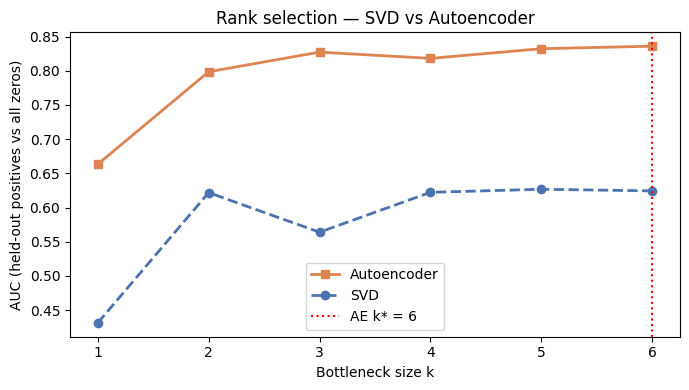

AE k* = 6  (held-out AUC = 0.8360)

Full AUC curve (Autoencoder):
  k= 1  AUC=0.6633
  k= 2  AUC=0.7986
  k= 3  AUC=0.8273
  k= 4  AUC=0.8182
  k= 5  AUC=0.8323
  k= 6  AUC=0.8360 <-- k*


In [11]:
ae_k_results = select_k_ae(
    R,
    k_range=range(1, 7),
    val_frac=0.2,
    random_state=42,
    selection_epochs=60,
    batch_size=32,
    plot=True,
    svd_auc_scores=k_results['auc_scores'],
)
K_STAR_AE = ae_k_results['k_star']

print("\nFull AUC curve (Autoencoder):")
for k, auc in sorted(ae_k_results['auc_scores'].items()):
    marker = " <-- k*" if k == K_STAR_AE else ""
    print(f"  k={k:2d}  AUC={auc:.4f}{marker}")

---
## Stage 4b — Autoencoder: training & scoring

Train the denoising autoencoder at the optimal bottleneck size k*.

The model is trained on the full interaction matrix R (with 80/20 client row split
for early stopping).  Input Dropout(0.3) corrupts the interaction vector during
training; the loss is computed against the original uncorrupted row — this is the
denoising objective that forces the encoder to learn inter-product co-occurrence
patterns rather than copying the sparse input.

`score_all_ae` returns sigmoid(logit) ∈ (0,1) for all (client, product) pairs,
interpretable as a purchase probability estimate given the client's observed history.

In [12]:
ae_model = train_autoencoder(
    R,
    k=K_STAR_AE,
    epochs=200,
    batch_size=32,
    val_frac=0.2,
    random_state=42,
    es_patience=20,
    verbose=True,
)
R_hat_ae = score_all_ae(ae_model, R)

print(f"\nBottleneck size    : k* = {K_STAR_AE}")
print(f"R_hat_ae shape     : {R_hat_ae.shape}")
print(f"Score range        : [{R_hat_ae.min():.4f}, {R_hat_ae.max():.4f}]")
print(f"Mean score (zeros) : {R_hat_ae[R == 0].mean():.4f}")
print(f"Mean score (ones)  : {R_hat_ae[R == 1].mean():.4f}")

  Epoch  50/200  val_loss=0.2056
  Epoch 100/200  val_loss=0.1831
  Epoch 150/200  val_loss=0.1834
  Early stop at epoch 199  (best val_loss=0.1765)

Bottleneck size    : k* = 6
R_hat_ae shape     : (5000, 11)
Score range        : [0.0000, 0.9984]
Mean score (zeros) : 0.1400
Mean score (ones)  : 0.9858


---
## Stage 4c — Autoencoder: constrained recommendations

Identical constraint logic to Stage 3c (SVD):

1. **Need type filter**: only products matching the client's confirmed need type.
2. **Risk cap**: SRI_p ≤ RiskPropensity_c (MiFID II hard constraint — never relaxed).

Products in the eligible set are ranked by descending AE score (sigmoid probability).

In [13]:
recs_ae = recommend_ae(
    client_indices=eligible_clients,
    R_hat_ae=R_hat_ae,
    clients_df=clients_df,
    products_df=products_df,
    top_n=1,
)

# --- Coverage metrics ---
n_served_ae  = recs_ae[recs_ae['status'] == 'ok']['client_idx'].nunique()
n_no_prod_ae = recs_ae[recs_ae['status'] == 'no_compliant_product']['client_idx'].nunique()

suit_pass_ae = (recs_ae[recs_ae['status'] == 'ok']['SRI']
                <= recs_ae[recs_ae['status'] == 'ok']
                    .merge(clients_df[['RiskPropensity']], left_on='client_idx', right_index=True)
                    ['RiskPropensity']).mean()

print(f"Eligible clients          : {n_eligible}")
print(f"Clients served (>= 1 rec) : {n_served_ae}  ({n_served_ae/n_eligible:.1%})")
print(f"Clients with no product   : {n_no_prod_ae}")
print(f"Suitability pass rate     : {suit_pass_ae:.1%}  (must be 100%)")

print("\nSample recommendations (first 15 rows):")
recs_ae.head(15)

Eligible clients          : 3465
Clients served (>= 1 rec) : 3303  (95.3%)
Clients with no product   : 185
Suitability pass rate     : 100.0%  (must be 100%)

Sample recommendations (first 15 rows):


,client_idx,need_type,rank,product_id,SRI,ae_score,status
0,0,Accumulation,1.0,P01,0.15,0.006336,ok
1,1,Income,1.0,P07,0.12,0.013159,ok
2,3,Income,1.0,P11,0.65,0.985343,ok
3,3,Accumulation,1.0,P04,0.56,0.027654,ok
4,5,Accumulation,1.0,P03,0.42,0.023808,ok
5,6,Accumulation,1.0,P02,0.28,0.024878,ok
6,7,Accumulation,1.0,P01,0.15,0.006336,ok
7,8,Income,1.0,P07,0.12,0.024216,ok
8,9,Income,1.0,P09,0.35,0.024789,ok
9,9,Accumulation,1.0,P03,0.42,0.452280,ok


---
## Stage 5 — Model comparison

### Per-model metrics

| Metric | Business meaning |
|---|---|
| **Coverage rate** | Fraction of the full 5,000-client base that receives ≥1 recommendation |
| **Suitability pass rate** | MiFID II compliance: SRI_p ≤ RiskPropensity_c for every recommendation |
| **Need alignment rate** | All recommendations match the client's confirmed need type (always 100% by construction) |
| **Avg propensity of served clients** | Whether the system prioritises high-confidence needs |

### Cross-model metrics

| Metric | Business meaning |
|---|---|
| **Recommendation overlap (Jaccard)** | High → both models redundant, pick simpler. Low → AE captures signal SVD cannot |
| **Coverage delta (AE − SVD)** | Whether non-linearity expands the served client base |
| **AUC difference** | Intrinsic quality gap from the rank-selection step |

In [14]:
n_total = len(clients_df)

# ── Per-model coverage & suitability ─────────────────────────────────────────
svd_ok = recs_svd[recs_svd['status'] == 'ok']
ae_ok  = recs_ae[recs_ae['status'] == 'ok']

coverage_svd = svd_ok['client_idx'].nunique() / n_total
coverage_ae  = ae_ok['client_idx'].nunique()  / n_total

suit_svd = (svd_ok['SRI']
            <= svd_ok.merge(clients_df[['RiskPropensity']], left_on='client_idx', right_index=True)
                     ['RiskPropensity']).mean()
suit_ae  = (ae_ok['SRI']
            <= ae_ok.merge(clients_df[['RiskPropensity']], left_on='client_idx', right_index=True)
                    ['RiskPropensity']).mean()

# Avg propensity of served clients
svd_served_idx = svd_ok['client_idx'].unique()
ae_served_idx  = ae_ok['client_idx'].unique()

avg_p_income_svd = clients_df.loc[
    clients_df.index.isin(svd_served_idx) & clients_df['need_income'], 'p_hat_income'
].mean()
avg_p_income_ae  = clients_df.loc[
    clients_df.index.isin(ae_served_idx) & clients_df['need_income'],  'p_hat_income'
].mean()

# ── Cross-model: recommendation overlap (Jaccard on top-1 per client/need) ───
def _top1_set(recs: pd.DataFrame) -> set:
    """Set of (client_idx, need_type, product_id) triples from top-1 rows."""
    return set(
        recs[recs['status'] == 'ok'][['client_idx', 'need_type', 'product_id']]
        .itertuples(index=False, name=None)
    )

svd_set = _top1_set(recs_svd)
ae_set  = _top1_set(recs_ae)
jaccard = len(svd_set & ae_set) / len(svd_set | ae_set) if svd_set | ae_set else 0.0

# ── AUC comparison (from rank-selection step) ────────────────────────────────
best_auc_svd = k_results['auc_scores'][K_STAR]
best_auc_ae  = ae_k_results['auc_scores'][K_STAR_AE]

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Coverage rate (of 5,000 clients)',
        'Suitability pass rate (MiFID II)',
        'Avg p_hat_income of served clients',
        'Held-out AUC (rank selection)',
        'Bottleneck size k*',
    ],
    'SVD': [
        f"{coverage_svd:.1%}",
        f"{suit_svd:.1%}",
        f"{avg_p_income_svd:.3f}",
        f"{best_auc_svd:.4f}",
        str(K_STAR),
    ],
    'Autoencoder': [
        f"{coverage_ae:.1%}",
        f"{suit_ae:.1%}",
        f"{avg_p_income_ae:.3f}",
        f"{best_auc_ae:.4f}",
        str(K_STAR_AE),
    ],
})

cross = pd.DataFrame({
    'Cross-model metric': [
        'Recommendation overlap (Jaccard)',
        'Coverage delta (AE - SVD)',
        'AUC delta (AE - SVD)',
    ],
    'Value': [
        f"{jaccard:.3f}",
        f"{coverage_ae - coverage_svd:+.1%}",
        f"{best_auc_ae - best_auc_svd:+.4f}",
    ],
})

print("Per-model metrics:")
display(summary.set_index('Metric'))

print("\nCross-model metrics:")
display(cross.set_index('Cross-model metric'))

Per-model metrics:


,SVD,Autoencoder
Metric,,
"Coverage rate (of 5,000 clients)",66.1%,66.1%
Suitability pass rate (MiFID II),100.0%,100.0%
Avg p_hat_income of served clients,0.704,0.704
Held-out AUC (rank selection),0.6267,0.8360
Bottleneck size k*,5,6



Cross-model metrics:


,Value
Cross-model metric,
Recommendation overlap (Jaccard),0.482
Coverage delta (AE - SVD),+0.0%
AUC delta (AE - SVD),+0.2093


In [15]:
# ── Final side-by-side sample: client_id | need_type | p_hat | SVD_top1 | AE_top1 | agree ──
def _top1_wide(recs: pd.DataFrame, score_col: str) -> pd.DataFrame:
    """Pivot top-1 rows to one row per (client_idx, need_type)."""
    tag = score_col.split('_')[0]   # 'svd_score' → 'svd', 'ae_score' → 'ae'
    ok  = recs[recs['status'] == 'ok'][['client_idx', 'need_type', 'product_id', 'SRI', score_col]]
    return ok.rename(columns={'product_id': f'product_{tag}', 'SRI': f'SRI_{tag}'})

svd_wide = _top1_wide(recs_svd, 'svd_score')
ae_wide  = _top1_wide(recs_ae,  'ae_score')

merged = svd_wide.merge(ae_wide, on=['client_idx', 'need_type'], how='outer')
merged = merged.merge(
    clients_df[['RiskPropensity', 'p_hat_income', 'p_hat_accum']],
    left_on='client_idx', right_index=True,
)

merged['p_hat'] = np.where(
    merged['need_type'] == 'Income',
    merged['p_hat_income'],
    merged['p_hat_accum'],
)
merged['agree'] = merged['product_svd'] == merged['product_ae']

sample = (merged[['client_idx', 'need_type', 'p_hat',
                   'product_svd', 'SRI_svd', 'product_ae', 'SRI_ae', 'agree']]
          .sort_values('client_idx')
          .head(10)
          .reset_index(drop=True))

print("Side-by-side sample (10 clients):")
display(sample)

Side-by-side sample (10 clients):


,client_idx,need_type,p_hat,product_svd,SRI_svd,product_ae,SRI_ae,agree
0,0,Accumulation,0.984696,P01,0.15,P01,0.15,True
1,1,Income,0.954745,P07,0.12,P07,0.12,True
2,3,Accumulation,1.000000,P04,0.56,P04,0.56,True
3,3,Income,1.000000,P10,0.50,P11,0.65,False
4,5,Accumulation,0.977729,P01,0.15,P03,0.42,False
5,6,Accumulation,0.998837,P01,0.15,P02,0.28,False
6,7,Accumulation,0.981302,P01,0.15,P01,0.15,True
7,8,Income,0.861500,P07,0.12,P07,0.12,True
8,9,Accumulation,0.427809,P03,0.42,P03,0.42,True
9,9,Income,1.000000,P08,0.22,P09,0.35,False
